In this notebook we will import a model trained on the UCD dataset and perform neural network pruning using a range of inverse models.

In [3]:
from sparseDPD import PGJANET_NeuralNetwork, PNTDNN_NeuralNetwork, ARVTDNN_NeuralNetwork
from sparseDPD import DataManager, Datapath, DatapathPruningExperiment, AdaptiveDatapathPruningExperiment


simpleDataManager = DataManager(filepath='../UCD_datasets/PA_IO.mat', num_training_points=19000, num_validaiton_points=1000, num_test_points=2000)

# Load forward model
PGJANET_forward_nn = PGJANET_NeuralNetwork(num_memory_levels=15, model_type='PGJANETNetwork', nn_file_path='../pre_trained_models/pgjanet_checkpoint.pt')

Using cuda device


# PNTDNN one layer

Using cuda device
Epoch  10/100  Loss=3.5276e+01  Valid Loss=1.8705e+01  LR=1.00e-03
Epoch  20/100  Loss=1.1448e+01  Valid Loss=1.3088e+01  LR=5.00e-04
Epoch  30/100  Loss=9.8238e+00  Valid Loss=1.2941e+01  LR=2.50e-04
Epoch  40/100  Loss=9.2128e+00  Valid Loss=1.2738e+01  LR=1.25e-04
Epoch  50/100  Loss=8.9076e+00  Valid Loss=1.2619e+01  LR=1.25e-04
Epoch  60/100  Loss=8.7402e+00  Valid Loss=1.2546e+01  LR=6.25e-05
Epoch  70/100  Loss=8.5922e+00  Valid Loss=1.2472e+01  LR=6.25e-05
Epoch  80/100  Loss=8.4413e+00  Valid Loss=1.2393e+01  LR=6.25e-05
Epoch  90/100  Loss=8.2893e+00  Valid Loss=1.2308e+01  LR=6.25e-05
Epoch 100/100  Loss=8.1374e+00  Valid Loss=1.2216e+01  LR=6.25e-05

Best model from epoch 100 with validation loss: 1.2216e+01
Iteration 1/10 (Block 1/1, samples 0-19000) - NMSE: -7.2812 dB
--------------------------------------------------
Epoch  10/100  Loss=8.7832e+00  Valid Loss=2.1069e+00  LR=1.00e-03
Epoch  20/100  Loss=4.9101e+00  Valid Loss=1.3321e+00  LR=1.00e-03
Epoc

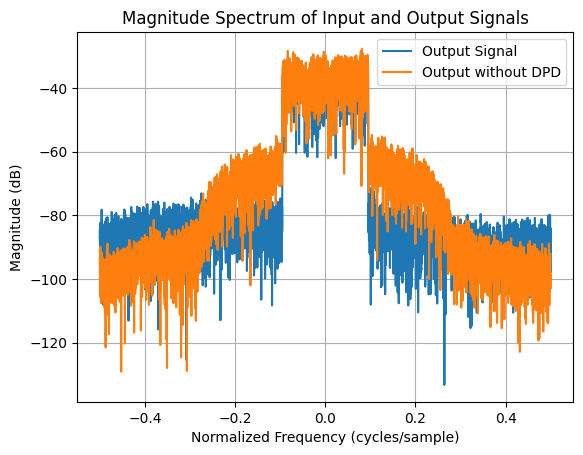

In [ ]:
# Train an inverse model based on this forward model
# Instantiate a new PNTDNN model for training (one layer)

PNTDNN_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path=None, forward_model=False)
# Create a datapath with this model and the forward model
datapath_pntdnn_one_layer = Datapath(forward_model=PGJANET_forward_nn, inverse_model=PNTDNN_inverse_nn)

datapath_pntdnn_one_layer.train_using_ila(
    training_dataset = simpleDataManager.training_dataset,
    valid_dataset = simpleDataManager.validation_dataset,
    iterations = 30,
    retrain_epochs_per_iteration=50,
    seq_length=None
)

# find nmse
nmse = datapath_pntdnn_one_layer.calculate_nmse(simpleDataManager.test_dataset.input_data)
print(f"NMSE: {nmse:.4f} dB")

# Plot the spectrum 
datapath_pntdnn_one_layer.plot_spectrum(simpleDataManager.test_dataset.input_data[:5000])

In [ ]:
# Save inverse model
PNTDNN_inverse_nn.write_nn_to_file('pntdnn_inverse_model.pt')

In [ ]:
PNTDNN_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path='pntdnn_inverse_model.pt', forward_model=False)
datapath_pntdnn_one_layer = Datapath(forward_model=PGJANET_forward_nn, inverse_model=PNTDNN_inverse_nn)



datapath_pntdnn_one_layer.plot_spectrum_with_aclr(
    simpleDataManager.test_dataset.input_data[:5000],
    channel_bw=0.2,
    channel_spacing=0.3
)

print(f"NMSE: (No DPD) {simpleDataManager.test_dataset.calculate_nmse():.4f} dB")

In [ ]:
# Now prune the inverse model and evaluate performance again
pruning_experiment_pntdnn_one_layer = DatapathPruningExperiment(
    datapath=datapath_pntdnn_one_layer,
    training_dataset=simpleDataManager.training_dataset,
    validation_dataset=simpleDataManager.validation_dataset,
    test_dataset=simpleDataManager.test_dataset,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=100,
    ila_iterations=1,
    nmse_tolerance=-40,
    seq_length=16384
)

pruning_experiment_pntdnn_one_layer.run()

# Save the best linear pruned inverse model
pruning_experiment_pntdnn_one_layer.best_datapath.inverse_model.write_nn_to_file('pntdnn_one_layer_fixed_percentage_pruned_inverse_model.pt')


In [ ]:
# Load best linear pruned model and evaluate performance
best_pruned_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path='pntdnn_one_layer_fixed_percentage_pruned_inverse_model.pt', forward_model=False)
#print sparsity of pruned model
print(f"Sparsity of pruned model: {best_pruned_inverse_nn._get_pruning_percentage():.2f}%")

best_pruned_datapath = Datapath(forward_model=PGJANET_forward_nn, inverse_model=best_pruned_inverse_nn)
# Plots for of best model
best_pruned_datapath.plot_spectrum_with_aclr(simpleDataManager.test_dataset.input_data[:5000], channel_bw=0.2, channel_bw=0.3)

In [ ]:
# Now try an adaptive pruning approach


adaptive_pruning_experiment = AdaptiveDatapathPruningExperiment(
    datapath=datapath_pntdnn_one_layer,
    training_dataset=simpleDataManager.training_dataset,
    validation_dataset=simpleDataManager.validation_dataset,
    test_dataset=simpleDataManager.test_dataset,
    retrain_epochs=100,
    ila_iterations = 1,
    initial_prune_fraction=0.2,
    max_prune_fraction=0.5,
    min_prune_fraction=0.01,
    nmse_tolerance=-40
)

adaptive_pruning_experiment.run()

print("Best NMSE after pruning: {:.4f} dB".format(adaptive_pruning_experiment.best_datapath.calculate_nmse(simpleDataManager.test_dataset.input_data)))

In [ ]:
# Save best adaptive pruned model
pntdnn_best_adaptive_pruned_model = adaptive_pruning_experiment.best_datapath.inverse_model
pntdnn_best_adaptive_pruned_model.write_nn_to_file('pntdnn_one_layer_adaptive_pruned_inverse_model_open.pt')

In [ ]:
# load the adaptive best, and find its performance
best_adaptive_pruned_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path='pntdnn_one_layer_adaptive_pruned_inverse_model_open.pt', forward_model=False)
best_adaptive_pruned_datapath = Datapath(forward_model=PGJANET_forward_nn, inverse_model=best_adaptive_pruned_inverse_nn)
best_adaptive_pruned_datapath.plot_constellation(simpleDataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)
best_adaptive_pruned_datapath.plot_spectrum_with_aclr(simpleDataManager.test_dataset.input_data[:5000], channel_bw=0.2, channel_bw=0.3)

# PG-JANET one layer

In [ ]:
# Train an inverse model based on this forward model
# Instantiate a new PG-JANET model for training (one layer)

PGJANET_inverse_nn = PGJANET_NeuralNetwork(num_memory_levels=15, model_type='PGJANETNetwork', nn_file_path=None, forward_model=False, batch_size=512, hidden_size=16)
# Create a datapath with this model and the forward model
datapath_pgjanet_one_layer = Datapath(forward_model=PGJANET_forward_nn, inverse_model=PGJANET_inverse_nn)

datapath_pgjanet_one_layer.train_using_ila(
    training_dataset = simpleDataManager.training_dataset,
    valid_dataset = simpleDataManager.validation_dataset,
    iterations = 10,
    retrain_epochs_per_iteration=50,
    seq_length=16834
)

# find nmse
nmse = datapath_pgjanet_one_layer.calculate_nmse(simpleDataManager.test_dataset.input_data)
print(f"NMSE: {nmse:.4f} dB")

# Plot the spectrum 
datapath_pgjanet_one_layer.plot_spectrum(simpleDataManager.test_dataset.input_data[:5000])

In [ ]:
# Save inverse model
PGJANET_inverse_nn.write_nn_to_file('pgjanet_inverse_model_open.pt')

In [ ]:
PGJANET_inverse_nn = PGJANET_NeuralNetwork(num_memory_levels=15, model_type='PGJANETNetwork', nn_file_path='pgjanet_inverse_model_open.pt', forward_model=False)
datapath_pgjanet_one_layer = Datapath(forward_model=PGJANET_forward_nn, inverse_model=PGJANET_inverse_nn)

# Evaluate model performance before pruning
openDPD_fs = 640e6  # Sampling frequency: 640 MHz
openDPD_bw_main_ch = 160e6  # Main channel bandwidth: 160 MHz
openDPD_bw_sub_ch = 40e6  # Sub-channel bandwidth: 40 MHz
openDPD_n_sub_ch = 4  # Number of sub-channels
openDPD_nperseg = 16384  # FFT size (frame length)

# Plot the QAM constellation - First check raw PA output (should be distorted)
print("Raw PA Output (no DPD):")
datapath_pgjanet_one_layer.plot_constellation(simpleDataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)

datapath_pgjanet_one_layer.plot_spectrum_with_aclr(
    simpleDataManager.test_dataset.input_data[:5000],
    channel_bw=0.2,
    channel_bw=0.3
)

print(f"NMSE: (No DPD) {simpleDataManager.test_dataset.calculate_nmse():.4f} dB")

In [ ]:
# Now prune the inverse model and evaluate performance again
pruning_experiment_pgjanet_one_layer = DatapathPruningExperiment(
    datapath=datapath_pgjanet_one_layer,
    training_dataset=simpleDataManager.training_dataset,
    validation_dataset=simpleDataManager.validation_dataset,
    test_dataset=simpleDataManager.test_dataset,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=100,
    ila_iterations=1,
    nmse_tolerance=-40,
    seq_length=16384
)

pruning_experiment_pgjanet_one_layer.run()

# Save the best linear pruned inverse model
pruning_experiment_pgjanet_one_layer.best_datapath.inverse_model.write_nn_to_file('pgjanet_one_layer_fixed_percentage_pruned_inverse_model_open.pt')

In [ ]:
# Load best linear pruned model and evaluate performance
best_pruned_pgjanet_inverse_nn = PGJANET_NeuralNetwork(num_memory_levels=15, model_type='PGJANETNetwork', nn_file_path='pgjanet_one_layer_fixed_percentage_pruned_inverse_model_open.pt', forward_model=False)
#print sparsity of pruned model
print(f"Sparsity of pruned model: {best_pruned_pgjanet_inverse_nn._get_pruning_percentage():.2f}%")

best_pruned_pgjanet_datapath = Datapath(forward_model=PGJANET_forward_nn, inverse_model=best_pruned_pgjanet_inverse_nn)
# Plots for of best model
best_pruned_pgjanet_datapath.plot_constellation(simpleDataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)
best_pruned_pgjanet_datapath.plot_spectrum_with_aclr(simpleDataManager.test_dataset.input_data[:5000], channel_bw=0.2, channel_bw=0.3)

In [ ]:
# Now try an adaptive pruning approach


adaptive_pruning_pgjanet_experiment = AdaptiveDatapathPruningExperiment(
    datapath=datapath_pgjanet_one_layer,
    training_dataset=simpleDataManager.training_dataset,
    validation_dataset=simpleDataManager.validation_dataset,
    test_dataset=simpleDataManager.test_dataset,
    retrain_epochs=100,
    ila_iterations = 1,
    initial_prune_fraction=0.2,
    max_prune_fraction=0.5,
    min_prune_fraction=0.01,
    nmse_tolerance=-40
)

adaptive_pruning_pgjanet_experiment.run()

print("Best NMSE after pruning: {:.4f} dB".format(adaptive_pruning_pgjanet_experiment.best_datapath.calculate_nmse(simpleDataManager.test_dataset.input_data)))

In [ ]:
# Save best adaptive pruned model
pgjanet_best_adaptive_pruned_model = adaptive_pruning_pgjanet_experiment.best_datapath.inverse_model
pgjanet_best_adaptive_pruned_model.write_nn_to_file('pgjanet_one_layer_adaptive_pruned_inverse_model_open.pt')

In [ ]:
# load the adaptive best, and find its performance
best_adaptive_pruned_pgjanet_inverse_nn = PGJANET_NeuralNetwork(num_memory_levels=15, model_type='PGJANETNetwork', nn_file_path='pgjanet_one_layer_adaptive_pruned_inverse_model_open.pt', forward_model=False)
best_adaptive_pruned_pgjanet_datapath = Datapath(forward_model=PGJANET_forward_nn, inverse_model=best_adaptive_pruned_pgjanet_inverse_nn)
best_adaptive_pruned_pgjanet_datapath.plot_constellation(simpleDataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)
best_adaptive_pruned_pgjanet_datapath.plot_spectrum_with_aclr(simpleDataManager.test_dataset.input_data[:5000], channel_bw=0.2, channel_bw=0.3)

# ARVTDNN one layer

Using cuda device
Epoch  10/50  Loss=5.2249e+00  Valid Loss=8.2317e+03  LR=1.00e-03
Epoch  20/50  Loss=3.0184e+00  Valid Loss=6.8090e+03  LR=1.00e-03
Epoch  30/50  Loss=2.1150e+00  Valid Loss=5.9814e+03  LR=1.00e-03
Epoch  40/50  Loss=1.5952e+00  Valid Loss=5.4612e+03  LR=1.00e-03
Epoch  50/50  Loss=1.2879e+00  Valid Loss=5.1234e+03  LR=1.00e-03

Best model from epoch 50 with validation loss: 5.1234e+03
Iteration 1/10 (Block 1/1, samples 0-294912) - NMSE: 3.0771 dB
--------------------------------------------------
Epoch  10/50  Loss=1.9750e+00  Valid Loss=1.5173e+03  LR=1.00e-03
Epoch  20/50  Loss=9.4349e-01  Valid Loss=6.9349e+02  LR=1.00e-03
Epoch  30/50  Loss=7.1003e-01  Valid Loss=6.1684e+02  LR=1.00e-03
Epoch  40/50  Loss=8.7370e-01  Valid Loss=5.9722e+02  LR=1.00e-03
Epoch  50/50  Loss=6.6652e-01  Valid Loss=5.6878e+02  LR=1.00e-03

Best model from epoch 50 with validation loss: 5.6878e+02
Iteration 2/10 (Block 1/1, samples 0-294912) - NMSE: -5.8421 dB
--------------------------

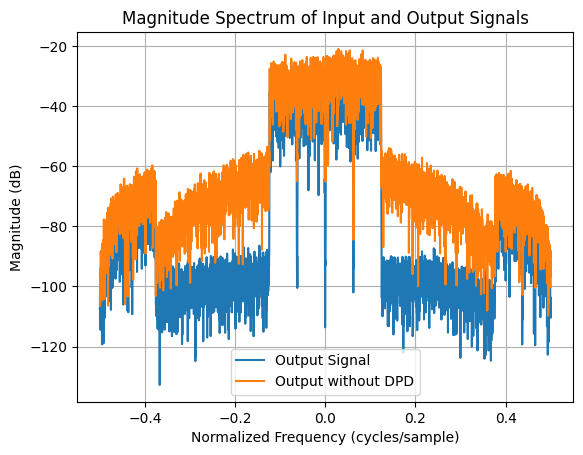

In [ ]:
# Train an inverse model based on this forward model
# Instantiate a new PNTDNN model for training (one layer)

ARVTDNN_inverse_nn = ARVTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path=None, forward_model=False)
# Create a datapath with this model and the forward model
datapath_arvtdnn_one_layer = Datapath(forward_model=PGJANET_forward_nn, inverse_model=ARVTDNN_inverse_nn)

datapath_arvtdnn_one_layer.train_using_ila(
    training_dataset = simpleDataManager.training_dataset,
    valid_dataset = simpleDataManager.validation_dataset,
    iterations = 10,
    retrain_epochs_per_iteration=50,
    seq_length=None
)

# find nmse
nmse = datapath_arvtdnn_one_layer.calculate_nmse(simpleDataManager.test_dataset.input_data)
print(f"NMSE: {nmse:.4f} dB")

# Plot the spectrum 
datapath_arvtdnn_one_layer.plot_spectrum(simpleDataManager.test_dataset.input_data[:5000])

# write to file 
ARVTDNN_inverse_nn.write_nn_to_file('arvtdnn_inverse_model_open.pt')

Using cuda device
Raw PA Output (no DPD):
Total subcarriers (1 carrier): 1024, Active (after guard band filtering): 982


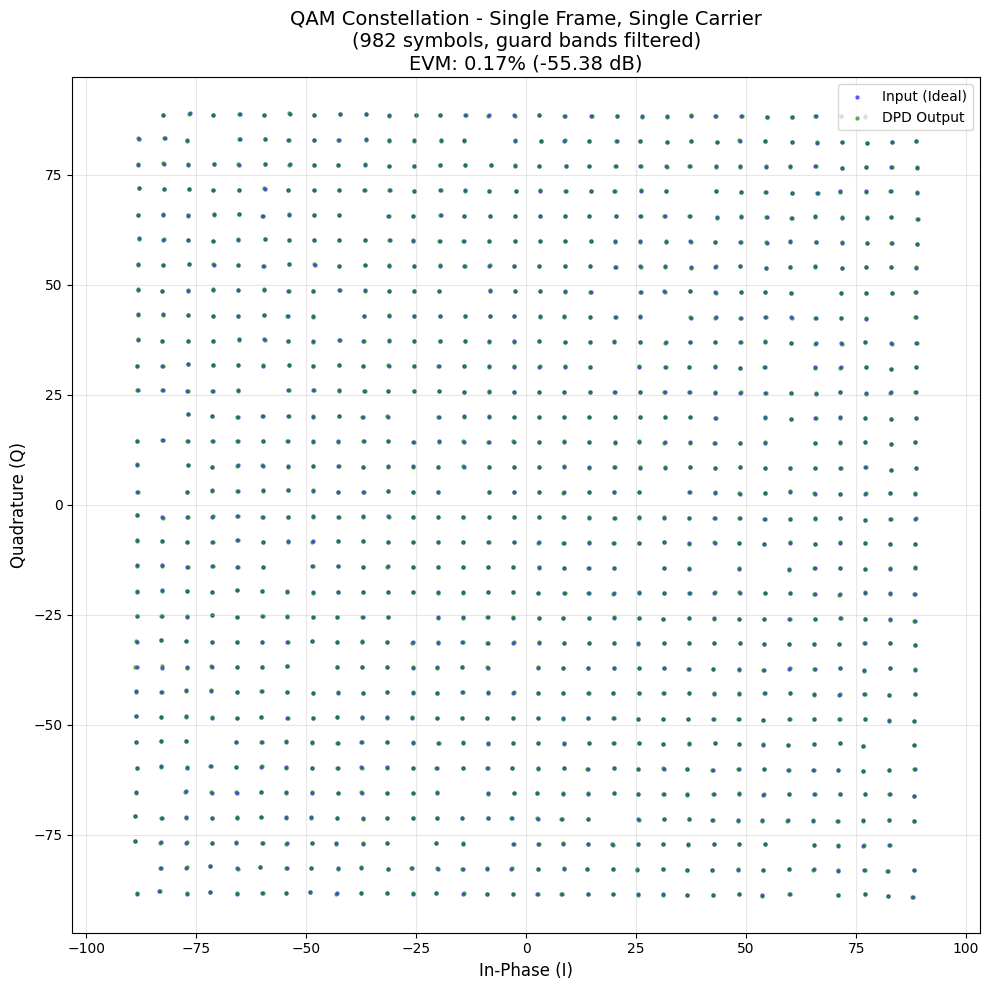

EVM (RMS): 0.170%
EVM (dB): -55.377 dB


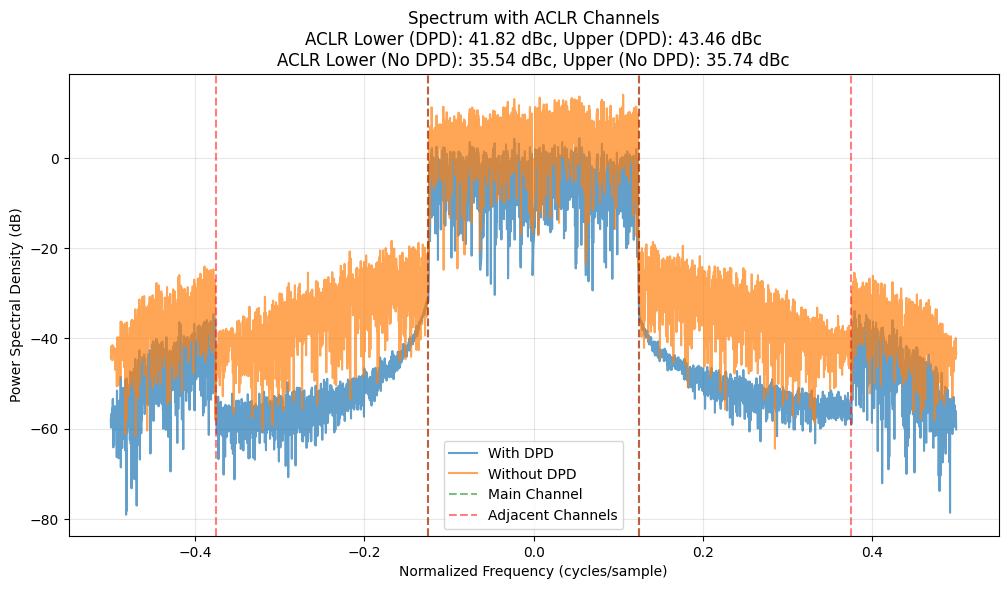

NMSE: (No DPD) 5.7197 dB


In [ ]:
ARVTDNN_inverse_nn = ARVTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path='arvtdnn_inverse_model_open.pt', forward_model=False)
datapath_arvtdnn_one_layer = Datapath(forward_model=PGJANET_forward_nn, inverse_model=ARVTDNN_inverse_nn)

# Evaluate model performance before pruning
openDPD_fs = 640e6  # Sampling frequency: 640 MHz
openDPD_bw_main_ch = 160e6  # Main channel bandwidth: 160 MHz
openDPD_bw_sub_ch = 40e6  # Sub-channel bandwidth: 40 MHz
openDPD_n_sub_ch = 4  # Number of sub-channels
openDPD_nperseg = 16384  # FFT size (frame length)

# Plot the QAM constellation - First check raw PA output (should be distorted)
print("Raw PA Output (no DPD):")
datapath_arvtdnn_one_layer.plot_constellation(simpleDataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)

datapath_arvtdnn_one_layer.plot_spectrum_with_aclr(
    simpleDataManager.test_dataset.input_data[:5000],
    channel_bw=0.2,
    channel_bw=0.3
)

print(f"NMSE: (No DPD) {simpleDataManager.test_dataset.calculate_nmse():.4f} dB")


Pruning Iteration 1/10
Pruning 20.0% of remaining weights...
Current pruning: 20.03% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=6.9990e-03  Valid Loss=2.9119e+01  LR=1.00e-03
Epoch  20/100  Loss=1.7540e-03  Valid Loss=2.3402e+01  LR=1.00e-03
Epoch  30/100  Loss=1.3722e-03  Valid Loss=2.0320e+01  LR=1.00e-03
Epoch  40/100  Loss=1.2045e-03  Valid Loss=1.8374e+01  LR=1.00e-03
Epoch  50/100  Loss=1.1066e-03  Valid Loss=1.7307e+01  LR=1.00e-03
Epoch  60/100  Loss=1.0448e-03  Valid Loss=1.6737e+01  LR=1.00e-03
Epoch  70/100  Loss=9.9388e-04  Valid Loss=1.6400e+01  LR=1.00e-03
Epoch  80/100  Loss=9.5712e-04  Valid Loss=1.6154e+01  LR=1.00e-03
Epoch  90/100  Loss=9.2151e-04  Valid Loss=1.6003e+01  LR=1.00e-03
Epoch 100/100  Loss=8.9335e-04  Valid Loss=1.5903e+01  LR=1.00e-03

Best model from epoch 100 with validation loss: 1.5903e+01
Iteration 1/1 (Block 1/18, samples 0-16384) - NMSE: -48.7766 dB
--------------------------------------------------
NMSE: -48.1136 dB

P

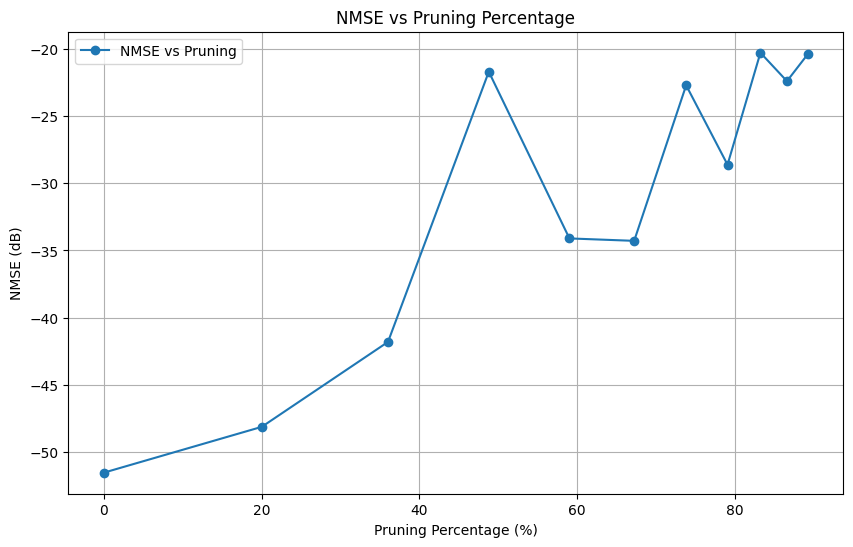

In [ ]:
# Now prune the inverse model and evaluate performance again
pruning_experiment_arvtdnn_one_layer = DatapathPruningExperiment(
    datapath=datapath_arvtdnn_one_layer,
    training_dataset=simpleDataManager.training_dataset,
    validation_dataset=simpleDataManager.validation_dataset,
    test_dataset=simpleDataManager.test_dataset,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=100,
    ila_iterations=1,
    nmse_tolerance=-40,
    seq_length=16384
)

pruning_experiment_arvtdnn_one_layer.run()

# Save the best linear pruned inverse model
pruning_experiment_arvtdnn_one_layer.best_datapath.inverse_model.write_nn_to_file('arvtdnn_one_layer_fixed_percentage_pruned_inverse_model_open.pt')


Using cuda device
Sparsity of pruned model: 0.00%
Total subcarriers (1 carrier): 1024, Active (after guard band filtering): 982


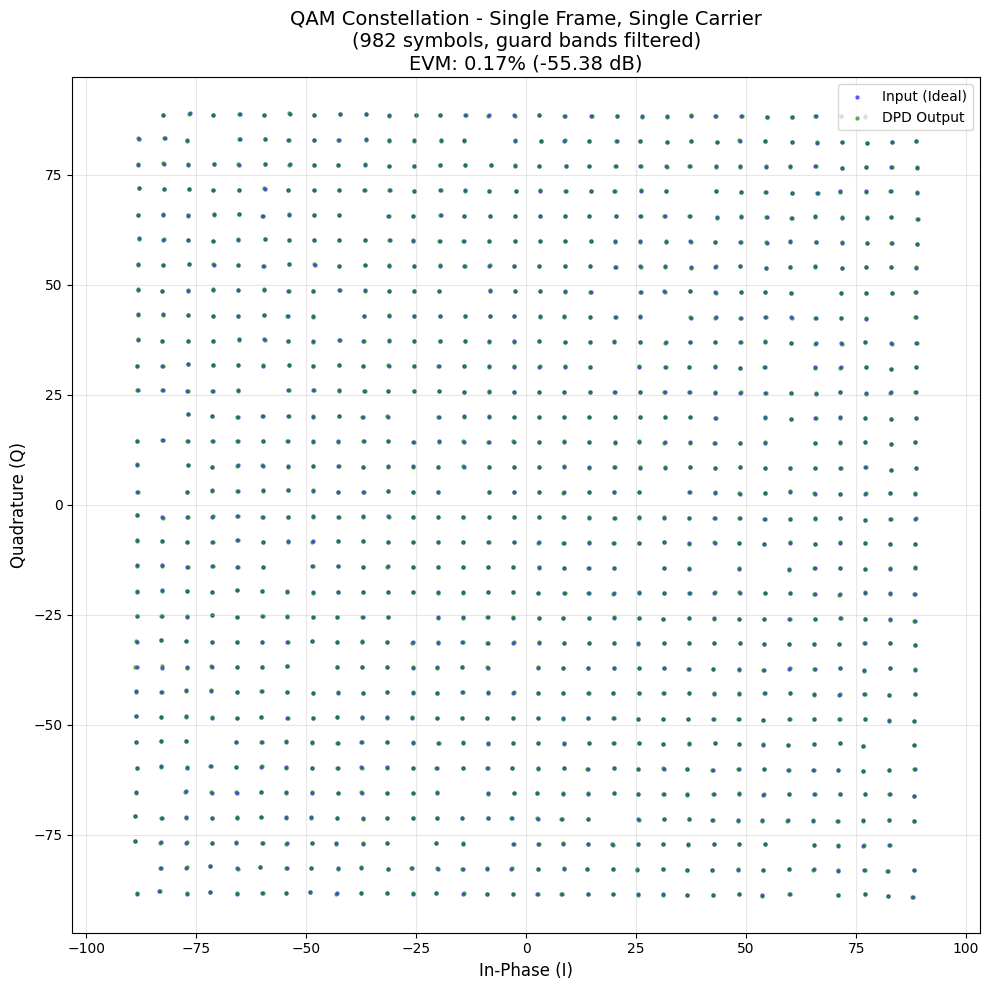

EVM (RMS): 0.170%
EVM (dB): -55.377 dB


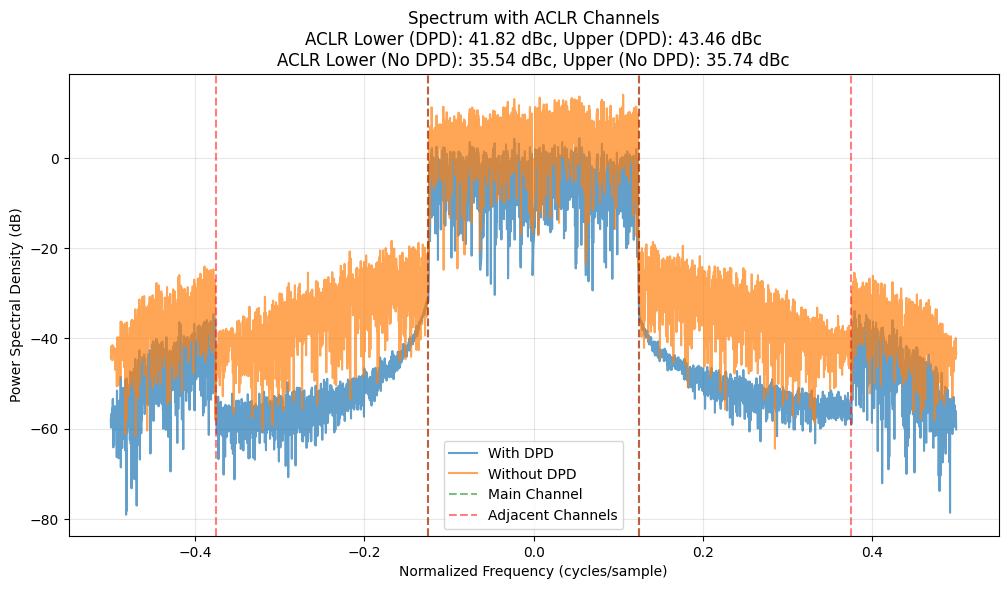

In [ ]:
# Load best linear pruned model and evaluate performance
best_pruned_inverse_nn = ARVTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path='arvtdnn_one_layer_fixed_percentage_pruned_inverse_model_open.pt', forward_model=False)
#print sparsity of pruned model
print(f"Sparsity of pruned model: {best_pruned_inverse_nn._get_pruning_percentage():.2f}%")

best_pruned_datapath = Datapath(forward_model=PGJANET_forward_nn, inverse_model=best_pruned_inverse_nn)
# Plots for of best model
best_pruned_datapath.plot_constellation(simpleDataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)
best_pruned_datapath.plot_spectrum_with_aclr(simpleDataManager.test_dataset.input_data[:5000], channel_bw=0.2, channel_bw=0.3)


Step 1  |  fraction = 20.00%
Pruning 20.00% of remaining weights...
Current sparsity: 20.03% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=2.3785e-02  Valid Loss=1.4962e+01  LR=1.00e-03
Epoch  20/100  Loss=2.2811e-02  Valid Loss=1.5044e+01  LR=1.00e-03
Epoch  30/100  Loss=2.0689e-02  Valid Loss=1.5032e+01  LR=5.00e-04
Epoch  40/100  Loss=2.0375e-02  Valid Loss=1.4916e+01  LR=2.50e-04
Epoch  50/100  Loss=1.9832e-02  Valid Loss=1.5048e+01  LR=1.25e-04
Epoch  60/100  Loss=1.9705e-02  Valid Loss=1.5155e+01  LR=6.25e-05
Epoch  70/100  Loss=1.9643e-02  Valid Loss=1.5142e+01  LR=3.13e-05
Epoch  80/100  Loss=1.9442e-02  Valid Loss=1.5171e+01  LR=3.13e-05
Epoch  90/100  Loss=1.9319e-02  Valid Loss=1.5156e+01  LR=1.56e-05
Epoch 100/100  Loss=1.9273e-02  Valid Loss=1.5166e+01  LR=7.81e-06

Best model from epoch 37 with validation loss: 1.4897e+01
Iteration 1/1 (Block 1/1, samples 0-294912) - NMSE: -49.7646 dB
--------------------------------------------------
NMSE: -49.550

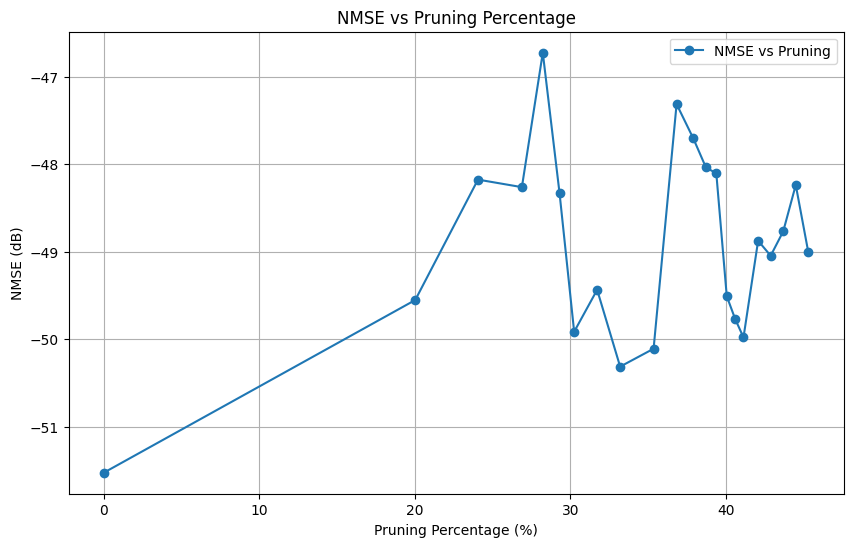

Best NMSE after pruning: -49.0043 dB


In [ ]:
# Now try an adaptive pruning approach


adaptive_pruning_experiment = AdaptiveDatapathPruningExperiment(
    datapath=datapath_arvtdnn_one_layer,
    training_dataset=simpleDataManager.training_dataset,
    validation_dataset=simpleDataManager.validation_dataset,
    test_dataset=simpleDataManager.test_dataset,
    retrain_epochs=100,
    ila_iterations = 1,
    initial_prune_fraction=0.2,
    max_prune_fraction=0.5,
    min_prune_fraction=0.01,
    nmse_tolerance=-40
)

adaptive_pruning_experiment.run()

print("Best NMSE after pruning: {:.4f} dB".format(adaptive_pruning_experiment.best_datapath.calculate_nmse(simpleDataManager.test_dataset.input_data)))

Using cuda device
Total subcarriers (1 carrier): 1024, Active (after guard band filtering): 982


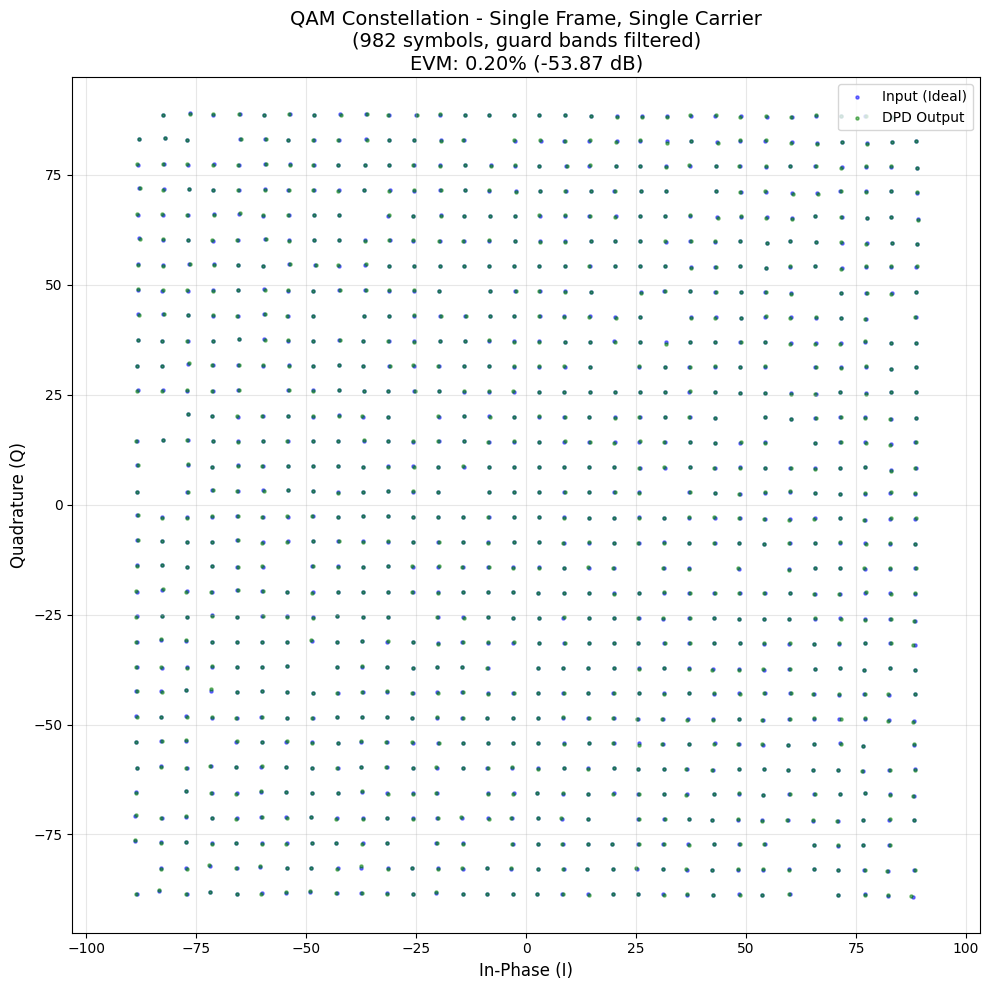

EVM (RMS): 0.203%
EVM (dB): -53.867 dB


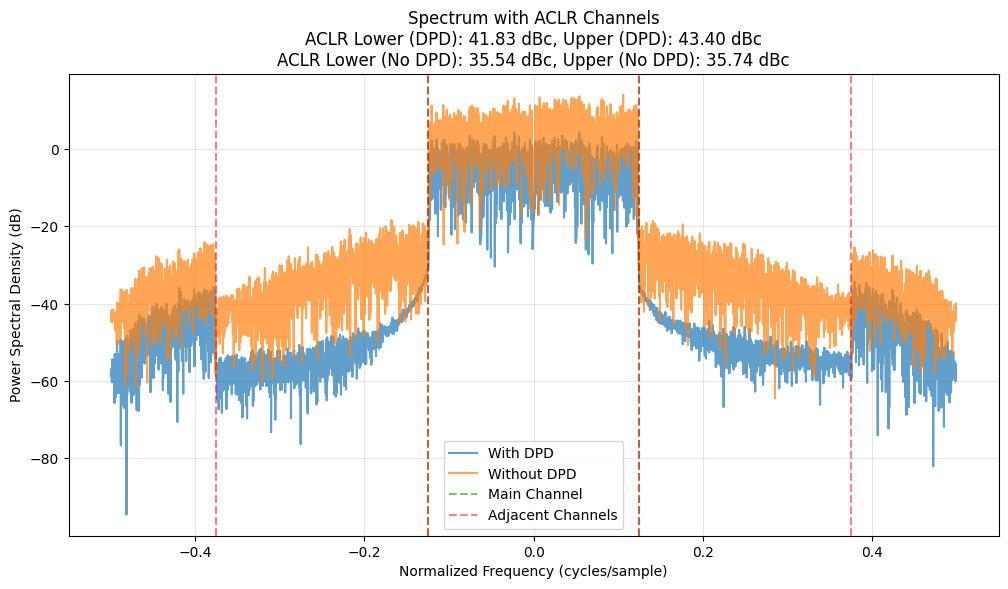

In [ ]:
# load the adaptive best, and find its performance
best_adaptive_pruned_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='OneLayerNetwork', nn_file_path='pntdnn_one_layer_adaptive_pruned_inverse_model_open.pt', forward_model=False)
best_adaptive_pruned_datapath = Datapath(forward_model=PGJANET_forward_nn, inverse_model=best_adaptive_pruned_inverse_nn)
best_adaptive_pruned_datapath.plot_constellation(simpleDataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)
best_adaptive_pruned_datapath.plot_spectrum_with_aclr(simpleDataManager.test_dataset.input_data[:5000], channel_bw=0.2, channel_bw=0.3)

# PNTDNN Two Layer

Using cuda device
Epoch  10/50  Loss=1.4160e+01  Valid Loss=1.0890e+03  LR=1.00e-03
Epoch  20/50  Loss=1.0634e+01  Valid Loss=6.0050e+02  LR=1.00e-03
Epoch  30/50  Loss=7.7956e+00  Valid Loss=3.3641e+02  LR=1.00e-03
Epoch  40/50  Loss=6.6746e+00  Valid Loss=2.6541e+02  LR=1.00e-03
Epoch  50/50  Loss=6.0495e+00  Valid Loss=2.3720e+02  LR=1.00e-03

Best model from epoch 49 with validation loss: 2.3716e+02
Iteration 1/25 (Block 1/1, samples 0-294912) - NMSE: -2.9125 dB
--------------------------------------------------
Epoch  10/50  Loss=2.6358e+00  Valid Loss=1.4724e+03  LR=1.00e-03
Epoch  20/50  Loss=2.2052e+00  Valid Loss=1.2528e+03  LR=5.00e-04
Epoch  30/50  Loss=2.0689e+00  Valid Loss=1.1118e+03  LR=2.50e-04
Epoch  40/50  Loss=2.0071e+00  Valid Loss=1.0553e+03  LR=1.25e-04
Epoch  50/50  Loss=1.9738e+00  Valid Loss=1.0177e+03  LR=6.25e-05

Best model from epoch 2 with validation loss: 9.7118e+02
Iteration 2/25 (Block 1/1, samples 0-294912) - NMSE: -6.5101 dB
--------------------------

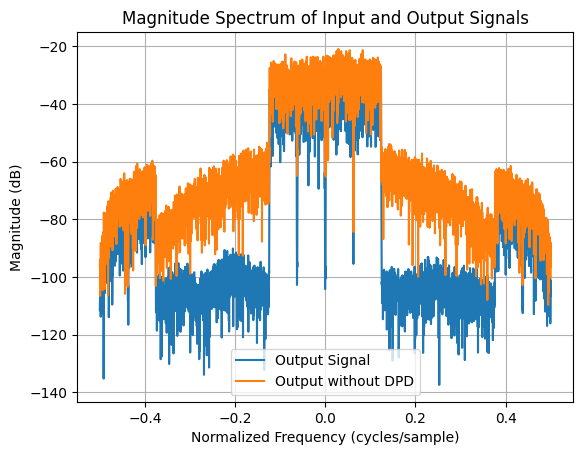

In [ ]:
# Train an inverse model based on this forward model
# Instantiate a new PNTDNN model for training (two layers)

PNTDNN_three_layer_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='ThreeLayerNetwork', nn_file_path=None, forward_model=False)
# Create a datapath with this model and the forward model
datapath_pntdnn_three_layer = Datapath(forward_model=PGJANET_forward_nn, inverse_model=PNTDNN_three_layer_inverse_nn)

datapath_pntdnn_three_layer.train_using_ila(
    training_dataset = simpleDataManager.training_dataset,
    valid_dataset = simpleDataManager.validation_dataset,
    iterations = 25,
    retrain_epochs_per_iteration=50,
    seq_length=None
)

# find nmse
nmse = datapath_pntdnn_three_layer.calculate_nmse(simpleDataManager.test_dataset.input_data)
print(f"NMSE: {nmse:.4f} dB")

# Plot the spectrum 
datapath_pntdnn_three_layer.plot_spectrum(simpleDataManager.test_dataset.input_data[:5000])

# Save model
datapath_pntdnn_three_layer.inverse_model.write_nn_to_file('pntdnn_three_layer_inverse_model_open.pt')

Using cuda device
Raw PA Output (no DPD):
Total subcarriers (1 carrier): 1024, Active (after guard band filtering): 982


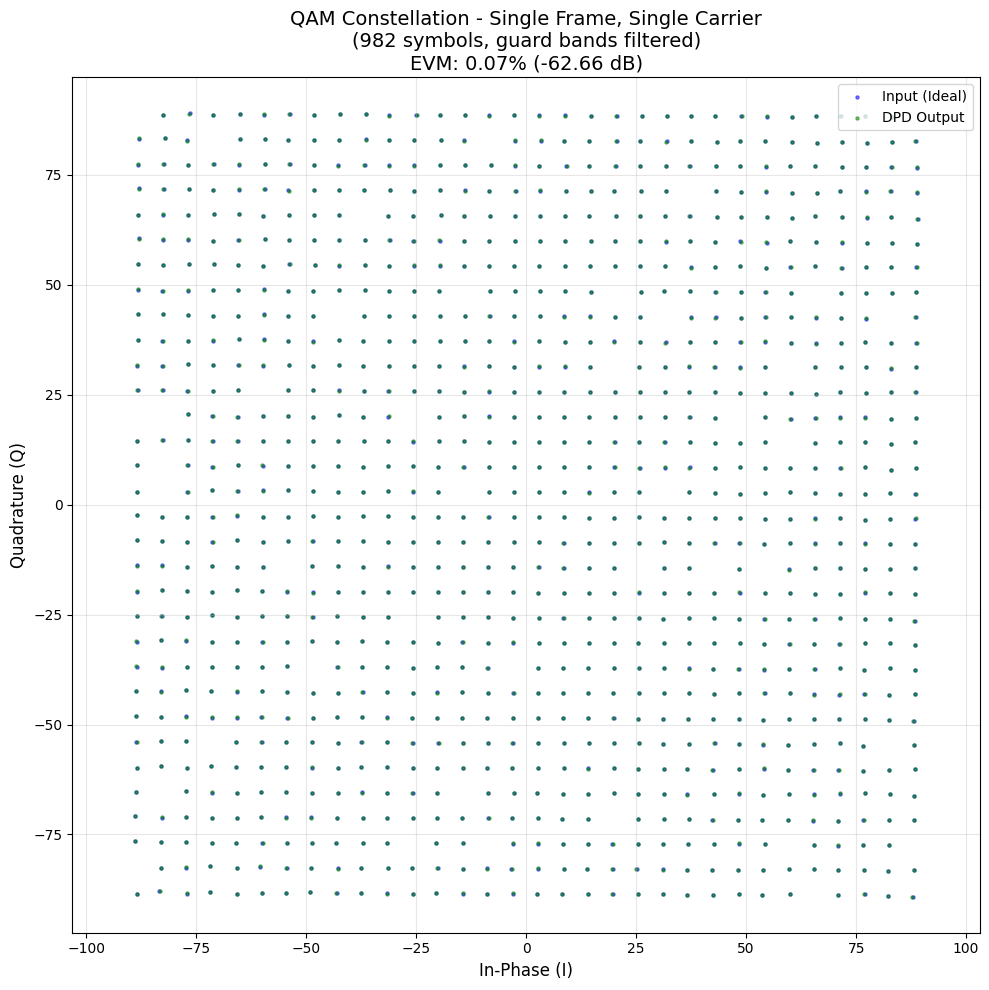

EVM (RMS): 0.074%
EVM (dB): -62.664 dB


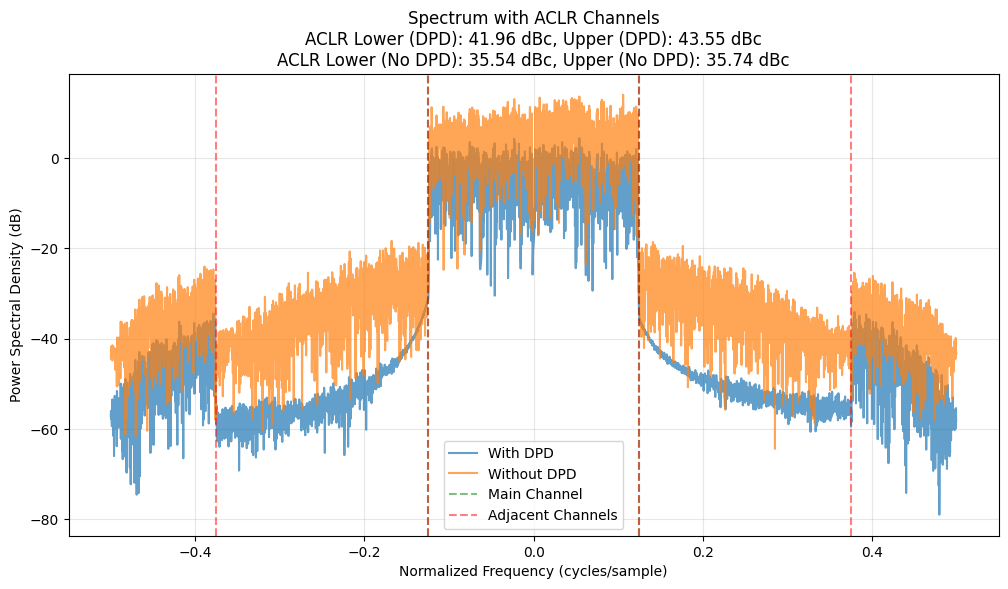

NMSE: (No DPD) 5.7197 dB


In [ ]:
PNTDNN_three_layer_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type='ThreeLayerNetwork', nn_file_path='pntdnn_three_layer_inverse_model_open.pt', forward_model=False)
datapath_pntdnn_three_layer = Datapath(forward_model=PGJANET_forward_nn, inverse_model=PNTDNN_three_layer_inverse_nn)

# Evaluate model performance before pruning
openDPD_fs = 640e6  # Sampling frequency: 640 MHz
openDPD_bw_main_ch = 160e6  # Main channel bandwidth: 160 MHz
openDPD_bw_sub_ch = 40e6  # Sub-channel bandwidth: 40 MHz
openDPD_n_sub_ch = 4  # Number of sub-channels
openDPD_nperseg = 16384  # FFT size (frame length)

# Plot the QAM constellation - First check raw PA output (should be distorted)
print("Raw PA Output (no DPD):")
datapath_pntdnn_three_layer.plot_constellation(simpleDataManager.training_dataset, fs = openDPD_fs, bw_sub_ch = openDPD_bw_sub_ch, n_sub_ch = openDPD_n_sub_ch, nperseg = openDPD_nperseg, show_dpd_output=True)

datapath_pntdnn_three_layer.plot_spectrum_with_aclr(
    simpleDataManager.test_dataset.input_data[:5000],
    channel_bw=0.2,
    channel_bw=0.3
)

print(f"NMSE: (No DPD) {simpleDataManager.test_dataset.calculate_nmse():.4f} dB")


Pruning Iteration 1/10
Pruning 20.0% of remaining weights...
Current pruning: 20.00% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=3.7353e-02  Valid Loss=4.2829e+01  LR=1.00e-03
Epoch  20/100  Loss=8.0095e-02  Valid Loss=4.1475e+01  LR=1.00e-03
Epoch  30/100  Loss=3.1626e-02  Valid Loss=4.1593e+01  LR=1.00e-03
Epoch  40/100  Loss=4.1577e-02  Valid Loss=4.0807e+01  LR=1.00e-03
Epoch  50/100  Loss=3.2637e-02  Valid Loss=4.0368e+01  LR=1.00e-03
Epoch  60/100  Loss=2.4999e-02  Valid Loss=4.0087e+01  LR=5.00e-04
Epoch  70/100  Loss=2.4581e-02  Valid Loss=3.9550e+01  LR=2.50e-04
Epoch  80/100  Loss=2.4463e-02  Valid Loss=3.9250e+01  LR=1.25e-04
Epoch  90/100  Loss=2.4304e-02  Valid Loss=3.9020e+01  LR=6.25e-05
Epoch 100/100  Loss=2.4305e-02  Valid Loss=3.8846e+01  LR=6.25e-05

Best model from epoch 100 with validation loss: 3.8846e+01
Iteration 1/1 (Block 1/1, samples 0-294912) - NMSE: -51.2432 dB
--------------------------------------------------
NMSE: -51.0669 dB

P

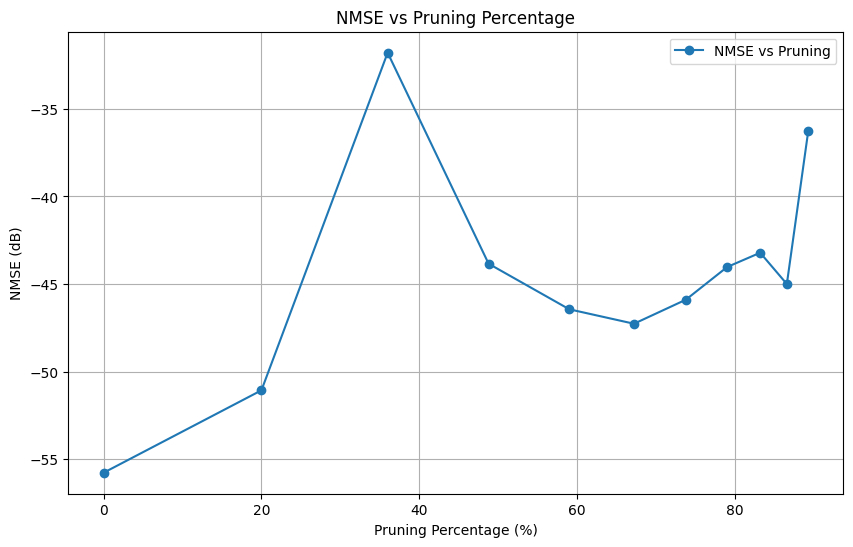

In [ ]:
# Now prune the inverse model and evaluate performance again
pruning_experiment_pntdnn_three_layer = DatapathPruningExperiment(
    datapath=datapath_pntdnn_three_layer,
    training_dataset=simpleDataManager.training_dataset,
    validation_dataset=simpleDataManager.validation_dataset,
    test_dataset=simpleDataManager.test_dataset,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=100,
    ila_iterations=1,
    nmse_tolerance=-40,
    seq_length=None
)

pruning_experiment_pntdnn_three_layer.run()

# Save the best linear pruned inverse model
pruning_experiment_pntdnn_three_layer.best_datapath.inverse_model.write_nn_to_file('pntdnn_three_layer_fixed_percentage_pruned_inverse_model_open.pt')
